In [3]:
import pandas as pd
import numpy as np
import os
import kagglehub
import torch

In [4]:
DATASET_PATH = "/kaggle/input/datasets/rvshekar/captcha-dataset-unified/captcha-unified"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
meta_df = pd.read_csv("/kaggle/input/datasets/rvshekar/captcha-dataset-unified/captcha-unified/metadata.csv")
train_df = pd.read_csv("/kaggle/input/datasets/rvshekar/captcha-dataset-unified/captcha-unified/train.csv")
test_df = pd.read_csv("/kaggle/input/datasets/rvshekar/captcha-dataset-unified/captcha-unified/test.csv")
val_df = pd.read_csv("/kaggle/input/datasets/rvshekar/captcha-dataset-unified/captcha-unified/val.csv")

train_df = train_df.drop(columns=["original_filename", "original_path", "extension", "sha256"])
test_df = test_df.drop(columns=["original_filename", "original_path", "extension", "sha256"])
val_df = val_df.drop(columns=["original_filename", "original_path", "extension", "sha256"])

train_df[65:70]

,image_id,label,source_type,captcha_length,image_path
65,49414,ahhgD,parsasam,5,images/parsasam/00049414.jpg
66,134759,c0DnsL9e9X,aadhavvignesh,10,images/aadhavvignesh/00134759.jpg
67,4400,KEBBMC,johnbergmann,6,images/johnbergmann/00004400.jpeg
68,90602,5RKyc,parsasam,5,images/parsasam/00090602.jpg
69,27449,efSsJ,parsasam,5,images/parsasam/00027449.jpg


In [6]:
i = 12345
img_path = os.path.join("/kaggle/input/datasets/rvshekar/captcha-dataset-unified/captcha-unified", train_df["image_path"][i])

os.path.exists(img_path)

True

In [7]:
print(val_df["captcha_length"].value_counts())

captcha_length
5     10299
6      1549
10      900
Name: count, dtype: int64


In [8]:
# testing the image dimensions

from PIL import Image
import numpy as np

sample_df = meta_df.sample(1000, random_state=42)

widths = []
heights = []
modes = []

for _, row in sample_df.iterrows():
    path = os.path.join(DATASET_PATH, row["image_path"])

    with Image.open(path) as img:
        widths.append(img.width)
        heights.append(img.height)
        modes.append(img.mode)

print("Width:")
print("  min:", min(widths))
print("  max:", max(widths))
print("  mean:", np.mean(widths))
print("  median:", np.median(widths))

print("\nHeight:")
print("  min:", min(heights))
print("  max:", max(heights))
print("  mean:", np.mean(heights))
print("  median:", np.median(heights))

print("\nImage modes:")
print(set(modes))

Width:
  min: 120
  max: 282
  mean: 168.948
  median: 150.0

Height:
  min: 40
  max: 90
  mean: 44.852
  median: 40.0

Image modes:
{'RGBA', 'RGB'}


In [9]:
# building character vocabulary for CTC

characters = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"

char2idx = {
    char : idx
    for idx, char in enumerate(characters)
}

idx2char = {
    idx : char
    for char, idx in char2idx.items()
}

BLANK_IDX = len(characters)

In [10]:
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader

class CaptchaDataset(Dataset):

    def __init__(self, df, dataset_path, char2idx, image_height=48):
        self.df = df
        self.dataset_path = dataset_path
        self.char2idx = char2idx
        self.image_height = image_height

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        #image
        image_path = os.path.join(self.dataset_path, row["image_path"])
        image = Image.open(image_path).convert("RGB")
        
        original_width, original_height = image.size

        new_height = self.image_height
        new_width = round((original_width * new_height) / original_height)

        image = image.resize((new_width, new_height), Image.Resampling.LANCZOS) # LANCOZ is an image interpolation method

        image = np.array(image, dtype=np.float32) / 255.0
        image_tensor = torch.from_numpy(image)
        image_tensor = image_tensor.permute(2, 0, 1)

        #label
        label = row["label"]

        encoded_label = torch.tensor([self.char2idx[c] for c in label], dtype=torch.long)

        return image_tensor, encoded_label, label, new_width

In [11]:
# creating all datasets

IMAGE_HEIGHT = 48

train_dataset = CaptchaDataset(
    train_df,
    DATASET_PATH,
    char2idx,
    IMAGE_HEIGHT
)

test_dataset = CaptchaDataset(
    test_df,
    DATASET_PATH,
    char2idx,
    IMAGE_HEIGHT
)

val_dataset = CaptchaDataset(
    val_df,
    DATASET_PATH,
    char2idx,
    IMAGE_HEIGHT
)

In [12]:
# collate function to manage the variable width of images in each batch

def captcha_collate_fn(batch):

    image_tensors, encoded_labels, labels, widths = zip(*batch)

    max_width = max(widths)
    batch_size = len(image_tensors)

    batch_images = torch.zeros(
        batch_size,
        3,
        IMAGE_HEIGHT,
        max_width,
        dtype = torch.float32
    )

    for i, img in enumerate(image_tensors):
        width = img.shape[2]
        batch_images[i, :, :, :width] = img

    targets = torch.cat(encoded_labels) # concatenating all the encoded_labels into a single tensor
    
    label_lengths = torch.tensor(
        [len(label) for label in labels],
        dtype = torch.long
    )

    widths = torch.tensor(widths, dtype=torch.long)

    return (batch_images, targets, label_lengths, labels, widths)

In [13]:
# creating dataloaders for all datasets

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    collate_fn = captcha_collate_fn,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = 4,
    pin_memory = True
)

test_loader = DataLoader(
    test_dataset,
    collate_fn = captcha_collate_fn,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = 4,
    pin_memory = True
)

val_loader = DataLoader(
    val_dataset,
    collate_fn = captcha_collate_fn,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = 4,
    pin_memory = True
)

In [14]:
# testing the loaders

image_tensors, targets, label_lengths, labels, widths = next(iter(train_loader))

print("Images shape:", image_tensors.shape)
print("Targets shape:", targets.shape)
print("Label lengths shape:", label_lengths.shape)

print("\nFirst 5 labels:")
print(labels[:5])

print("\nFirst 5 encoded labels:")
print(targets[:sum(label_lengths[:5])])

print("\nFirst 5 original widths:")
print(widths[:5])

Images shape: torch.Size([128, 3, 48, 240])
Targets shape: torch.Size([697])
Label lengths shape: torch.Size([128])

First 5 labels:
('s9yYO', 'b2LKU', 'PzLYM', 'FVpuD', 'g3KT4')

First 5 encoded labels:
tensor([54,  9, 60, 34, 24, 37,  2, 21, 20, 30, 25, 61, 21, 34, 22, 15, 31, 51,
        56, 13, 42,  3, 20, 29,  4])

First 5 original widths:
tensor([180, 180, 180, 180, 180])


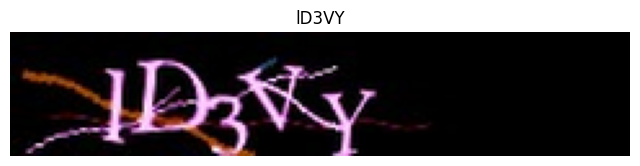

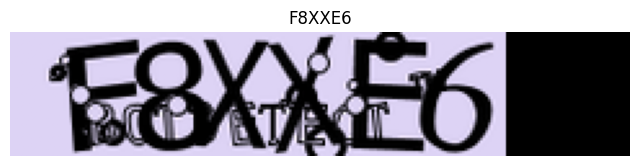

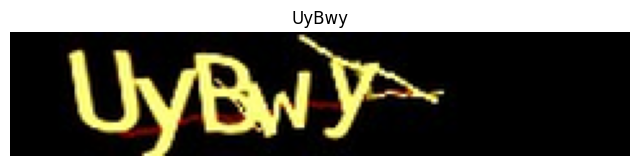

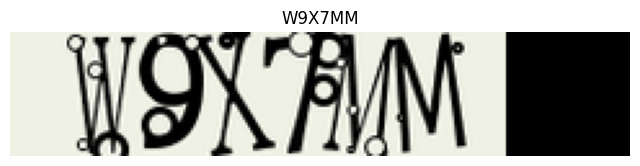

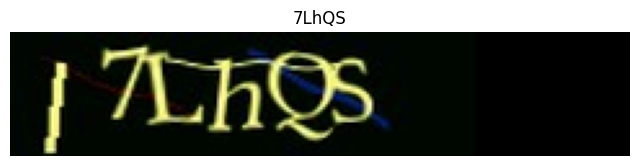

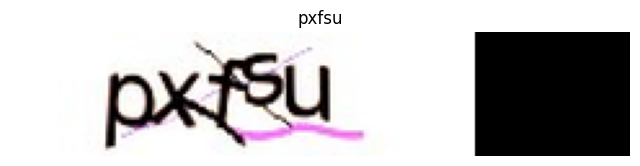

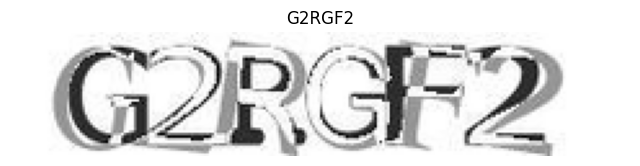

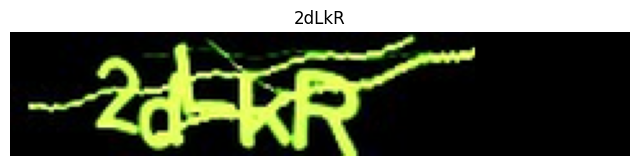

In [33]:
# manually inspecting the image after preprocessing

import matplotlib.pyplot as plt

images, targets, label_lengths, labels, widths = next(iter(train_loader))

for i in range(8):
    plt.figure(figsize=(8, 2))
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title(labels[i])
    plt.axis("off")
    plt.show()

In [27]:
# building the CNN

import torch
import torch.nn as nn

class CNNEncoder(nn.Module):
    
    def __init__(self):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.cnn(x)


cnn_encoder = CNNEncoder()

In [28]:
# testing the cnn output size

image_tensors, targets, label_lengths, labels, widths = next(iter(train_loader))

img_features = cnn_encoder(image_tensors)

print("Input shape:", image_tensors.shape)
print("CNN output shape:", img_features.shape)

Input shape: torch.Size([128, 3, 48, 240])
CNN output shape: torch.Size([128, 256, 12, 60])


In [29]:
class BiLSTM(nn.Module):
    def __init__(self, input_size=1538, projection_size=256, hidden_size=128):
        super().__init__()

        self.projection = nn.Linear(input_size, projection_size)

        self.lstm = nn.LSTM(
            input_size = projection_size,
            hidden_size = hidden_size,
            bidirectional = True
        )

    def forward(self, x):
        x = self.projection(x)
        x, _ = self.lstm(x) # [W, B, 128+128] because of forward + backward
        return x


bilstm_encoder = BiLSTM()

In [30]:
import torch.nn.functional as F

class CharacterClassifier(nn.Module):
    def __init__(self, input_size=256, num_classes=63):
        super().__init__()

        self.fc = nn.Linear(input_size, num_classes)

    def forward(self, x):
        x = self.fc(x)
        return x


character_classifier = CharacterClassifier()

In [31]:
class CAPTCHARecognizer(nn.Module):
    def __init__(self, cnn, bilstm, classifier):
        super().__init__()
        
        self.cnn = cnn
        self.bilstm = bilstm
        self.classifier = classifier

    def forward(self, x):
        x = self.cnn(x)

        # reshaping the output from cnn in order to feed the BiLSTM
        B, C, H, W = x.shape
        x = x.permute(3, 0, 1, 2)
        x = x.reshape(W, B, C*H)

        x = self.bilstm(x)
        x = self.classifier(x)

        return x

In [32]:
model = CAPTCHARecognizer(
    cnn = cnn_encoder,
    bilstm = bilstm_encoder,
    classifier = character_classifier
)

model = model.to(device)

In [22]:
# testing the model 

image_tensors, targets, label_lengths, labels, widths = next(iter(train_loader))
image_tensors = image_tensors.to(device, non_blocking=True)

logits = model(image_tensors)
print(logits)

tensor([[[ 0.0290,  0.0277, -0.0422,  ...,  0.0339, -0.1164,  0.0873],
         [ 0.0390, -0.0316,  0.0172,  ...,  0.0463,  0.0268, -0.0115],
         [ 0.0150,  0.0256, -0.0467,  ...,  0.0484, -0.0932,  0.0752],
         ...,
         [ 0.0420, -0.0068,  0.0707,  ...,  0.0362, -0.0165, -0.0302],
         [ 0.0415, -0.0142,  0.0522,  ...,  0.0207,  0.0263, -0.0599],
         [ 0.0376, -0.0258,  0.0391,  ...,  0.0225,  0.0331, -0.0506]],

        [[ 0.0570,  0.0743, -0.0862,  ...,  0.0265, -0.1114,  0.0969],
         [ 0.0586, -0.0328,  0.0285,  ...,  0.0432,  0.0347, -0.0235],
         [ 0.0395,  0.0652, -0.0486,  ...,  0.0564, -0.0869,  0.0701],
         ...,
         [ 0.0696, -0.0023,  0.0715,  ...,  0.0196, -0.0091, -0.0048],
         [ 0.0631, -0.0060,  0.0662,  ...,  0.0110,  0.0375, -0.0465],
         [ 0.0427, -0.0208,  0.0464,  ...,  0.0175,  0.0585, -0.0464]],

        [[ 0.0881,  0.0704, -0.0979,  ..., -0.0039, -0.1210,  0.0209],
         [ 0.0800, -0.0179,  0.0343,  ...,  0

In [23]:
criterion = nn.CTCLoss(blank=BLANK_IDX, zero_infinity=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [24]:
# creating sample loaders to test the training loop

from torch.utils.data import DataLoader, Subset

test_train_dataset = Subset(
    train_dataset,
    range(min(200, len(train_dataset)))
)

test_val_dataset = Subset(
    val_dataset,
    range(min(50, len(val_dataset)))
)

test_train_loader = DataLoader(
    test_train_dataset,
    collate_fn = captcha_collate_fn,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

test_val_loader = DataLoader(
    test_val_dataset,
    collate_fn = captcha_collate_fn,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [26]:
import time

epochs = 50

best_val_loss = float("inf")

for epoch in range(epochs):

    epoch_start_time = time.time()

    # Training
    model.train()

    total_train_loss = 0.0
    total_train_samples = 0

    for batch_images, targets, label_lengths, labels, widths in train_loader:

        batch_images = batch_images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        label_lengths = label_lengths.to(device, non_blocking=True)
        input_lengths = (widths // 4).to(device, non_blocking=True)

        optimizer.zero_grad()

        # Forward pass
        logits = model(batch_images)

        # CTC expects log probabilities
        log_probs = logits.log_softmax(dim=2)

        # CTC loss
        loss = criterion(
            log_probs,
            targets,
            input_lengths,
            label_lengths
        )

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        batch_size = batch_images.size(0)

        total_train_loss += loss.item() * batch_size
        total_train_samples += batch_size

    avg_train_loss = total_train_loss / total_train_samples

    # VALIDATION
    model.eval()

    total_val_loss = 0.0
    total_val_samples = 0

    correct_captchas = 0
    total_captchas = 0

    with torch.no_grad():

        for batch_images, targets, label_lengths, labels, widths in val_loader:

            batch_images = batch_images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            label_lengths = label_lengths.to(device, non_blocking=True)
            input_lengths = (widths // 4).to(device, non_blocking=True)

            # Forward pass
            logits = model(batch_images)

            # CTC loss
            log_probs = logits.log_softmax(dim=2)

            loss = criterion(
                log_probs,
                targets,
                input_lengths,
                label_lengths
            )

            batch_size = batch_images.size(0)

            total_val_loss += loss.item() * batch_size
            total_val_samples += batch_size

            # Greedy CTC decoding
            predictions = logits.argmax(dim=2)

            for i in range(batch_size):

                pred = predictions[:input_lengths[i], i]

                decoded = []
                previous = None

                for char_id in pred.tolist():

                    # 62 is the CTC blank
                    if char_id == 62:
                        previous = char_id
                        continue

                    # Remove consecutive duplicates
                    if char_id != previous:
                        decoded.append(char_id)

                    previous = char_id

                # Convert IDs to characters
                predicted_text = "".join(idx2char[idx] for idx in decoded)

                actual_text = labels[i]

                if predicted_text == actual_text:
                    correct_captchas += 1

                total_captchas += 1

    avg_val_loss = total_val_loss / total_val_samples
    exact_match_acc = correct_captchas / total_captchas

    epoch_time = (time.time() - epoch_start_time) / 60

    print(
        f"Epoch: {epoch + 1}/{epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Exact Match: {exact_match_acc:.4%} | "
        f"Time: {epoch_time:.2f} mins"
    )


    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_captcha_model.pth")
        print("Best model saved.")

    # Save checkpoint
    torch.save(
        {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "val_exact_match_accuracy": exact_match_acc,
            "best_val_loss": best_val_loss
        },
        "ckpt_captcha_model.pth"
    )

Epoch: 1/50 | Train Loss: 2.9980 | Val Loss: 1.0521 | Exact Match: 19.1010% | Time: 5.09 mins
Best model saved.
Epoch: 2/50 | Train Loss: 0.6686 | Val Loss: 0.5148 | Exact Match: 45.5915% | Time: 1.53 mins
Best model saved.
Epoch: 3/50 | Train Loss: 0.4003 | Val Loss: 0.3543 | Exact Match: 57.6169% | Time: 1.41 mins
Best model saved.
Epoch: 4/50 | Train Loss: 0.3061 | Val Loss: 0.3243 | Exact Match: 59.6564% | Time: 1.41 mins
Best model saved.
Epoch: 5/50 | Train Loss: 0.2557 | Val Loss: 0.2992 | Exact Match: 61.6881% | Time: 1.41 mins
Best model saved.
Epoch: 6/50 | Train Loss: 0.2216 | Val Loss: 0.2579 | Exact Match: 66.6457% | Time: 1.42 mins
Best model saved.
Epoch: 7/50 | Train Loss: 0.1972 | Val Loss: 0.2467 | Exact Match: 68.8422% | Time: 1.41 mins
Best model saved.
Epoch: 8/50 | Train Loss: 0.1786 | Val Loss: 0.2416 | Exact Match: 68.8186% | Time: 1.41 mins
Best model saved.
Epoch: 9/50 | Train Loss: 0.1645 | Val Loss: 0.2387 | Exact Match: 68.0656% | Time: 1.48 mins
Best model

Exception in thread Thread-49 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    do_one_step()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/multiprocessing/reductions.py", line 540, in rebuild_storage_fd
    fd = df.detach()
         ^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/resource_

KeyboardInterrupt: 